# Titanic Deep Learning Model
This notebook loads the dataset, processes features, scales them, and trains a deep neural network to predict passenger survival.

**Architecture:**
- Input layer 
- 128 (ReLU)
- 64 (ReLU)
- 32 (ReLU)
- 1 (Sigmoid output)

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
import os

### 1. Load the Dataset
Since this is in the `titanic dataset` folder, we can just load the local CSV.

In [9]:
csv_path = 'huge_1M_titanic.csv'
model_save_path = 'titanic_model.keras'

print(f"Loading data from {csv_path}...")
df = pd.read_csv(csv_path)

Loading data from huge_1M_titanic.csv...


### 2. Splitting the Dataset Before Preprocessing
To prevent **Data Leakage**, we must split the dataset into training and testing subsets *before* computing any statistics like median or mode for imputation. If we compute it using the entire `df`, the testing set leaks into the training set.

In [10]:
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=columns_to_drop)

# Separate features (X) and target variable (y - Survived)
X = df.drop(columns=['Survived'])
y = df['Survived']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into train and test without leaking information.")

Data split into train and test without leaking information.


### 3. Feature Imputation, Encoding & Scaling
Now we compute the median/mode **exclusively** from `X_train` and use it to fill missing values in both `X_train` and `X_test`. Then we scale the features.

In [11]:
print("Handling missing values safely (No Data Leakage)...")
# Compute statistics from X_train ONLY
age_median = X_train['Age'].median()
embarked_mode = X_train['Embarked'].mode()[0]
fare_median = X_train['Fare'].median()

# Fill missing values
X_train['Age'] = X_train['Age'].fillna(age_median)
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_train['Fare'] = X_train['Fare'].fillna(fare_median)

X_test['Age'] = X_test['Age'].fillna(age_median)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)
X_test['Fare'] = X_test['Fare'].fillna(fare_median)

print("Encoding categorical variables...")
X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True).astype(float)
X_test = pd.get_dummies(X_test, columns=['Sex', 'Embarked'], drop_first=True).astype(float)

# Ensure columns align and no mismatches between train and test dummies
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Handling missing values safely (No Data Leakage)...
Encoding categorical variables...
Scaling features...


### 4. Build and Train the Deep Learning Model
Setting up the 128 -> 64 -> 32 -> 1 Sequential structure.

In [12]:
print("Building model architecture...")
model = Sequential()

# Input layer + First hidden layer with 128 neurons
model.add(Input(shape=(X_train_scaled.shape[1],)))
model.add(Dense(128, activation='relu'))

# Second hidden layer with 64 neurons
model.add(Dense(64, activation='relu'))

# Third hidden layer with 32 neurons
model.add(Dense(32, activation='relu'))

# Output layer with 1 neuron (Sigmoid activation for classification)
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Building model architecture...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Training the model (max 10 epochs) with **Early Stopping**.

In [13]:
print("Training the model...")

# Utilizing early stopping to watch loss trajectory
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Training with a large batch size for the big dataset and constrained to 10 epochs
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=10, 
    batch_size=2048, 
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)

Training the model...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8450 - loss: 0.3643 - val_accuracy: 0.8612 - val_loss: 0.3247
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8656 - loss: 0.3136 - val_accuracy: 0.8671 - val_loss: 0.3060
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8693 - loss: 0.3022 - val_accuracy: 0.8699 - val_loss: 0.2985
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8725 - loss: 0.2964 - val_accuracy: 0.8720 - val_loss: 0.2949
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8743 - loss: 0.2935 - val_accuracy: 0.8754 - val_loss: 0.2931
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8758 - loss: 0.2909 - val_accuracy: 0.8778 - val_loss: 0.2883
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8764 - loss: 0.2894 - val_accuracy: 0.8757 - val_loss: 0.2885
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8775 - loss: 0.2

### 5. Evaluate and Save
Evaluating the predictions, printing the confusion matrix, plotting it, and saving the model.


Test Loss: 0.2867, Test Accuracy: 0.8786

--- Evaluating Model Predictions ---

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 644us/step
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90    123847
           1       0.87      0.80      0.83     76153

    accuracy                           0.88    200000
   macro avg       0.88      0.86      0.87    200000
weighted avg       0.88      0.88      0.88    200000



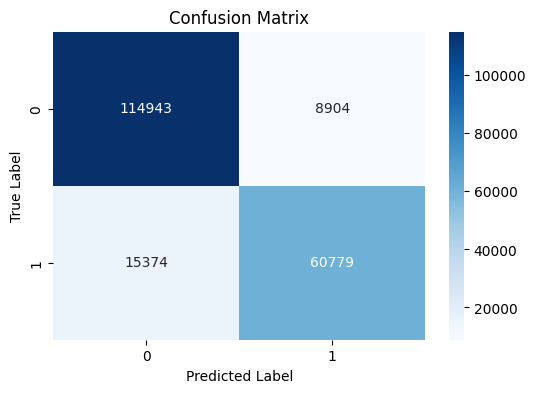


Model successfully saved to titanic_model.keras


In [14]:
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

print("\n--- Evaluating Model Predictions ---\n")
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

model.save(model_save_path)
print(f"\nModel successfully saved to {model_save_path}")